# Imágenes --> Tensores

> **Una imagen es simplemente un Stack de 3 Matrices empalmadas.**

Como si fuera un Excel con 3 pestañas:
1.  **Hoja R (Red):** Contiene números del 0 al 255 que indican "qué tan rojo" es cada punto.
2.  **Hoja G (Green):** Contiene números del 0 al 255 que indican la intensidad del verde.
3.  **Hoja B (Blue):** Contiene números del 0 al 255 para el azul.

El **Pixel** en la coordenada $(i, j)$ no es más que un vector de 3 dimensiones $[r, g, b]$ que vive en esa celda específica a través de las 3 hojas.

### Definición Matemática

-   Una imagen en **Escala de Grises** es una matriz: $X \in \mathbb{R}^{H \times W}$ (Alto $\times$ Ancho).
-   Una imagen a **Color (RGB)** es un tensor de orden 3: $X \in \mathbb{R}^{C \times H \times W}$ (Canales $\times$ Alto $\times$ Ancho).


In [1]:
import os
import requests
from io import BytesIO

import numpy as np
from PIL import Image

import torch
from torchvision import transforms as T

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

## Cargar una imagen

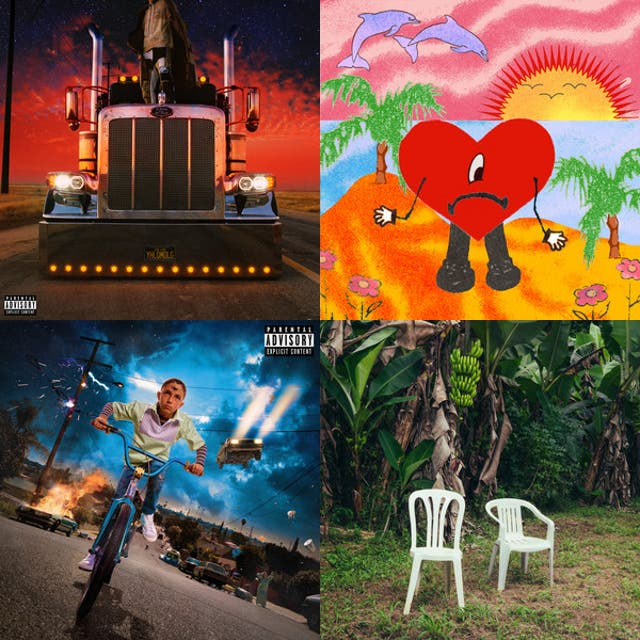

In [2]:
# URL de la imagen
url = "https://mosaic.scdn.co/640/ab67616d00001e02005ee342f4eef2cc6e8436abab67616d00001e0249d694203245f241a1bcaa72ab67616d00001e02548f7ec52da7313de0c5e4a0ab67616d00001e02bbd45c8d36e0e045ef640411"

# Cargamos la imagen como un arreglo de NumPy (nuestra hoja de cálculo)
response = requests.get(url)
image = Image.open(BytesIO(response.content))

display(image)

Para la computadora esto es solo una colección de intensidades lumínicas.

In [3]:
transform = T.ToTensor()
tensor_img = transform(image)

print(f"Tipo de dato: {type(tensor_img)}")
print(f"Dimensiones originales (Canales, Alto, Ancho): {tensor_img.shape}")

tensor_img[0][0][:10]

Tipo de dato: <class 'torch.Tensor'>
Dimensiones originales (Canales, Alto, Ancho): torch.Size([3, 640, 640])


tensor([0.0510, 0.1059, 0.1059, 0.0863, 0.0941, 0.0745, 0.0667, 0.1216, 0.0667,
        0.0824])

## Tres canales?

-   **Canal Rojo (R):** Índice 0
-   **Canal Verde (G):** Índice 1
-   **Canal Azul (B):** Índice 2

Entonces:
-   **Valor 0 (Negro):** Ausencia total de ese color.
-   **Valor 255 (Blanco):** Máxima intensidad de ese color.

In [4]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

def plot_rgb_and_channels(tensor):
    # 1. Preparar la imagen RGB (Convertir a 0-255 uint8)
    # Importante: multiplicamos por 255 porque tu tensor está en rango 0-1
    img_rgb_np = (tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    # 2. Extraer canales (mantener floats para los Heatmaps)
    r_chan = tensor[0, :, :].numpy()
    g_chan = tensor[1, :, :].numpy()
    b_chan = tensor[2, :, :].numpy()

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=("Original (RGB)", "Canal Rojo", "Canal Verde", "Canal Azul"),
        horizontal_spacing=0.08,
        vertical_spacing=0.15
    )

    # Subplot 1: Imagen Original (Ahora con datos uint8)
    fig.add_trace(go.Image(z=img_rgb_np), row=1, col=1)

    # Subplots de canales con Heatmaps
    # Usamos zmin/zmax 0 y 1 para que la intensidad sea real respecto al total
    fig.add_trace(go.Heatmap(z=r_chan, coloraxis="coloraxis1", zmin=0, zmax=1), row=1, col=2)
    fig.add_trace(go.Heatmap(z=g_chan, coloraxis="coloraxis2", zmin=0, zmax=1), row=2, col=1)
    fig.add_trace(go.Heatmap(z=b_chan, coloraxis="coloraxis3", zmin=0, zmax=1), row=2, col=2)

    # Configuración de escalas de colores
    fig.update_layout(
        height=800, width=800,
        coloraxis1=dict(colorscale=[[0, 'white'], [1, 'red']], showscale=False),
        coloraxis2=dict(colorscale=[[0, 'white'], [1, 'green']], showscale=False),
        coloraxis3=dict(colorscale=[[0, 'white'], [1, 'blue']], showscale=False),
        template="plotly_white"
    )

    # Corregir ejes: Invertimos Y para que no salgan de cabeza y mantenemos proporción
    fig.update_yaxes(autorange="reversed", scaleanchor="x", scaleratio=1)

    # IMPORTANTE: En algunas versiones de Plotly, go.Image ya viene bien orientado.
    # Si la original se ve de cabeza, cambia "reversed" a True en la línea de abajo:
    fig.update_yaxes(autorange="reversed", row=1, col=1)

    fig.show()

In [5]:
plot_rgb_and_channels(tensor_img)

Output hidden; open in https://colab.research.google.com to view.

## 3. Normalización: El Idioma de la Red


In [6]:
tensor_img.min(),  tensor_img.max()

(tensor(0.), tensor(1.))

## 4. Manipulación de Tensores

### A. Crop (Recorte)
Recortar una imagen es simplemente hacer **Slicing** de la matriz, es decir, sólo seleccionamos esas filas y columnas.

In [7]:
# URL de la imagen
url = "https://image.europafm.com/clipping/cmsimages01/2026/02/09/CC6C3742-473B-4F67-B27E-BE43CD7B073A/chaqueta-traje-bad-bunny-super-bowl-2026_98.jpg"

# Cargamos la imagen como un arreglo de NumPy (nuestra hoja de cálculo)
response = requests.get(url)
image = Image.open(BytesIO(response.content))

display(image)

Output hidden; open in https://colab.research.google.com to view.

In [8]:
tensor_img = transform(image)

print(tensor_img.shape)

torch.Size([3, 1069, 1900])


In [14]:
# Hacemos slice: Todos los canales, Filas, Columnas
crop_tensor = tensor_img[:, 400:700, 300:800]

# Para graficar con plotly, necesitamos regresar a (H, W, C)
crop_display = crop_tensor.permute(1, 2, 0).numpy()

fig = px.imshow(crop_display, title="Recorte (Slicing de Matriz)")
fig.show()

### B. Brillo (Brightness)

¿Qué significa aumentar el brillo? Simplemente sumar un escalar a toda la matriz.
Es como agregar un "bono" a todos los empleados en una nómina de Excel.

$$ X_{nuevo} = X_{viejo} + \delta $$

In [15]:
# Aumentamos el brillo sumando X a todo el tensor
# .clamp(0, 1) asegura que no nos pasemos de 1.0 (que sería blanco puro)
bright_tensor = (tensor_img + 0.5).clamp(0, 1)

bright_display = bright_tensor.permute(1, 2, 0).numpy()

fig = px.imshow(bright_display, title="Aumento de Brillo (Suma de Escalar)")
fig.show()

### C. Rotación (Transformación Espacial)

Rotar una imagen es una operación más compleja que sumar escalares, ya que implica remapear las coordenadas $(x, y)$.

Usaremos `torchvision.transforms.functional` (que suele venir con PyTorch). En Deep Learning, rotar imágenes aleatoriamente (Data Augmentation) ayuda a que el modelo no se vuelva "perezoso" y aprenda a reconocer objetos sin importar su orientación.

In [19]:
import random
import torchvision.transforms.functional as TF

# Rotamos la imagen
rotated_tensor = TF.rotate(tensor_img, angle=random.randint(1,364))

rotated_display = rotated_tensor.permute(1, 2, 0).numpy()
fig = px.imshow(rotated_display, title="Rotación")
fig.show()

## 5. Ejercicio Final: Tu Propio Laboratorio de Imágenes

¡Es hora de practicar! El objetivo es que apliques lo aprendido a una imagen de tu elección.

**Instrucciones:**
1. Busca una URL de una imagen en Google (que termine en .jpg o .png).
2. Cámbiala en la variable `mi_url` abajo.
3. Crea un bucle (loop) que genere **5 versiones diferentes** de la imagen aplicando transformaciones aleatorias (puedes variar el recorte, el brillo o el ángulo de rotación).
4. Muestra las 5 imágenes resultantes.

In [ ]:
import random
import torchvision.transforms.functional as TF

mi_url = "https://scontent.fgdl17-1.fna.fbcdn.net/v/t1.6435-9/118580725_1423815027811902_6159177032798750972_n.png?stp=dst-jpg_tt6&_nc_cat=100&ccb=1-7&_nc_sid=13d280&_nc_ohc=Kay5Vbw6ZsYQ7kNvwHefcVz&_nc_oc=AdmXAfzkLolSxS_Uq4GSYryslIOyDM7mKBZoo7VLdmiKdCrYFu7wFpad6rF9-hYIouyjYXkTb4ni2ApwosEiaqLU&_nc_zt=23&_nc_ht=scontent.fgdl17-1.fna&_nc_gid=0M2wC4nyLZ7kyPngNKYxQg&oh=00_AfsFniZyeRPgSb9qLo26WtnhEmTjYeoaUSsZj1nSCBPKQQ&oe=69C5962F"

try:
    response = requests.get(mi_url)
    image = Image.open(BytesIO(response.content))

    display(image)

    tensor_img = transform(image)
    print(tensor_img.shape)

    print("Generando 5 variaciones aleatorias...")

    for i in range(5):
        # --- TRANSFOMACIONES ALEATORIAS ---
        # Ángulo entre -60 y 60 grados
        deg = random.uniform(-60, 60)
        t_mod = TF.rotate(tensor_img, angle=deg)

        # Brillo entre -0.2 y 0.3
        val_brillo = random.uniform(-0.2, 0.3)
        t_mod = (t_mod + val_brillo).clamp(0, 1)

        # Mostrar
        img_out = t_mod.permute(1, 2, 0).numpy()
        fig = px.imshow(img_out, title=f"Variación {i+1}: Rot={deg:.1f}°, Brillo={val_brillo:.2f}")
        fig.show()

except Exception as e:
    print(f"Error al procesar la imagen: {e}")
    print("Tip: Asegúrate de que la URL sea directa a un archivo de imagen (.jpg, .png).")

Output hidden; open in https://colab.research.google.com to view.